## Lorenz63 Benchmarks

### config


In [1]:
import torch
from lorenz import Lorenz63, TimeAveragedFeatures

N = 500
T = 250 
spinup =25 
dt = 0.01
params = {
    'sigma':10,
    'beta':8/3,
    'rho':28 
}
l63 = Lorenz63(**params)
x0 = torch.randn((N,3))
l63_avg = TimeAveragedFeatures(l63,spinup=spinup)

r_avg = l63_avg(x0,T,dt)


In [2]:
from torch.distributions import MultivariateNormal
stats = MultivariateNormal(r_avg.mean(dim=0),torch.cov(r_avg.T))
stats_mean = MultivariateNormal(r_avg.mean(dim=0),torch.cov(r_avg.T)/N)

### calibration

In [13]:
from torch.distributions import MultivariateNormal,Uniform
from abracalibra.forward_model import ForwardModel

priors = {
    'sigma':Uniform(5,15),
    'beta':Uniform(1,5),
    'rho':Uniform(25,30)
} # these are probably too wide priors!


N = 25
x0 = torch.randn((N,3))

def lorenz63(sigma,beta,rho):
    with torch.no_grad():
        l = TimeAveragedFeatures(Lorenz63(sigma.clone(),beta.clone(),rho.clone()),spinup=spinup)
        fwd = l(x0,T,dt)
        return fwd

fwd = ForwardModel(lorenz63,vectorized=False,out_shape=torch.Size([N,9]))

In [ ]:
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask
from scipy.stats import chi2
from abracalibra.summary import implausibility_multivariate_distr
parameters = ['sigma','beta','rho']
def summary(y,true_y):
    return implausibility_multivariate_distr(y,true_y)

priors = {
    'sigma':Uniform(9,11),
    'beta':Uniform(2,3),
    'rho':Uniform(25,30)
} # th
cutoff = chi2(stats_mean.mean.shape[0]).ppf(0.95)
hm = HistoryMatchingMultiTask(parameters,priors,stats_mean,ensemble_size=50,summary=summary,forward=fwd,implausibility_cutoff=cutoff)
hm.calibrate(1)

In [5]:


nroy,coords= hm.nroy_over_support(num_points=100,return_coords=True)

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [7]:
from gpytorch.settings import fast_pred_var
emulator = hm.emulators[0]
emulator.eval()

coords = hm.get_support_axis(0,100)
X,Y = torch.meshgrid(*coords,indexing='ij')
with fast_pred_var(), torch.no_grad():
    pred = emulator(torch.stack([X,Y],dim=-1).view(-1,2))
    imp = hm.implausibility(torch.stack([X,Y],dim=-1).view(-1,2),0)
    
pred_mean = pred.mean.view(100,100,9)
imp = imp.view(100,100)


torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [8]:
emulator.likelihood.raw_noise

Parameter containing:
tensor([4.3791], requires_grad=True)

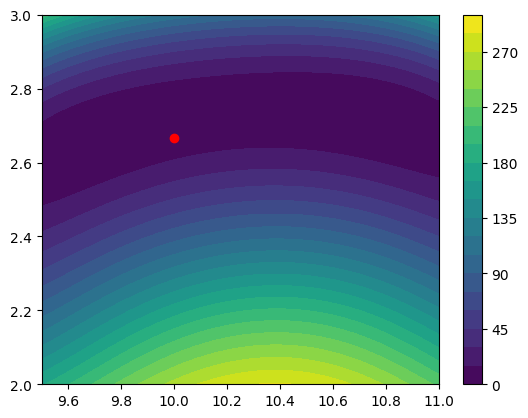

In [11]:
import matplotlib.pyplot as plt
plt.contourf(X,Y,imp,levels=25) 

plt.colorbar()
plt.scatter([params['sigma']],[params['beta']],color='r')

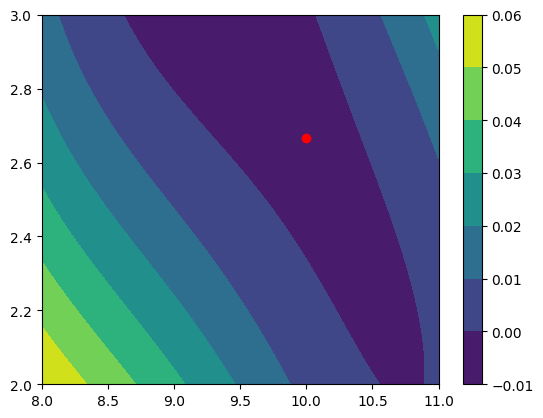

In [23]:

pred_nth = pred_mean[...,0]
plt.contourf(X,Y,pred_nth) 
plt.colorbar()
plt.scatter([params['sigma']],[params['beta']],color='r')

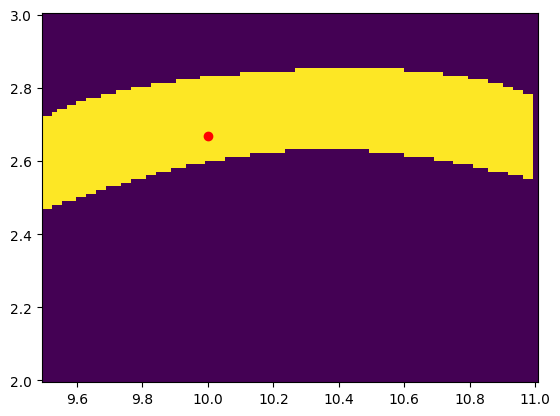

In [12]:
fig,ax = plt.subplots()
ax.pcolormesh(X,Y,nroy)
ax.scatter([params['sigma']],[params['beta']],color='r')

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

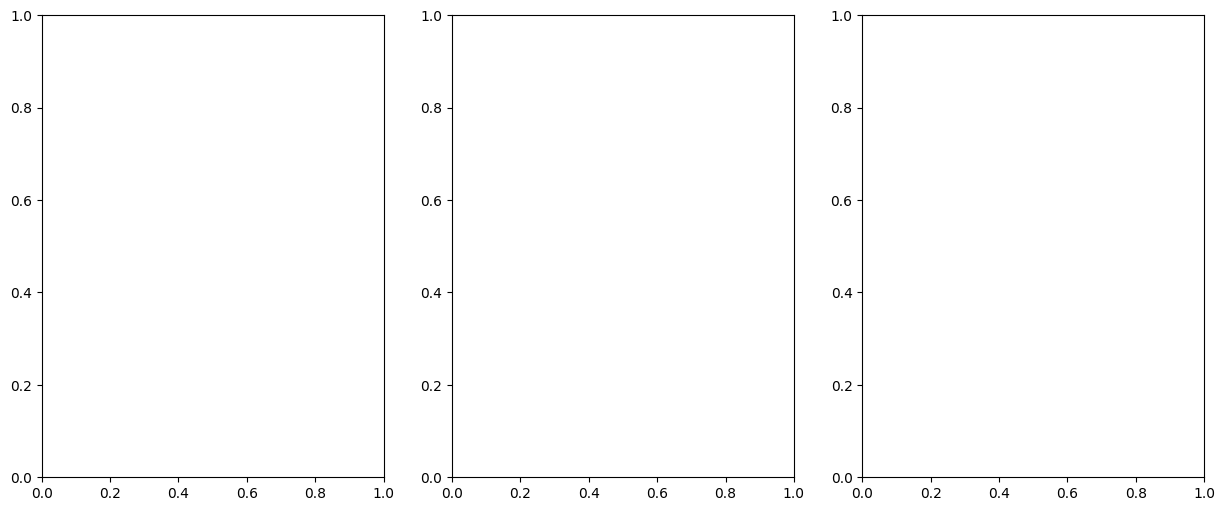

In [15]:
import matplotlib.pyplot as plt
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,6))
X,Y = torch.meshgrid(coords[0],coords[1],indexing='xy')
ax1.pcolormesh(X,Y,nroy.sum(dim=2)/100)
ax1.scatter(params['sigma'],params['beta'],color='r')

X,Y = torch.meshgrid(coords[1],coords[2],indexing='xy')
ax2.pcolormesh(X,Y,nroy.sum(dim=0)/100)
ax2.scatter(params['beta'],params['rho'],color='r')
X,Y = torch.meshgrid(coords[2],coords[0],indexing='xy')
ax3.pcolormesh(X,Y,nroy.sum(dim=1)/100)
ax3.scatter(params['rho'],params['sigma'],color='r')

In [14]:
from abracalibra.eki import EnsembleKalmanInversion

eki = EnsembleKalmanInversion(parameters,priors,observables,ensemble_size=30,forward=fwd)
eki.calibrate(5)

tensor([ 9.9812,  2.6643, 27.9959], grad_fn=<MeanBackward1>)

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

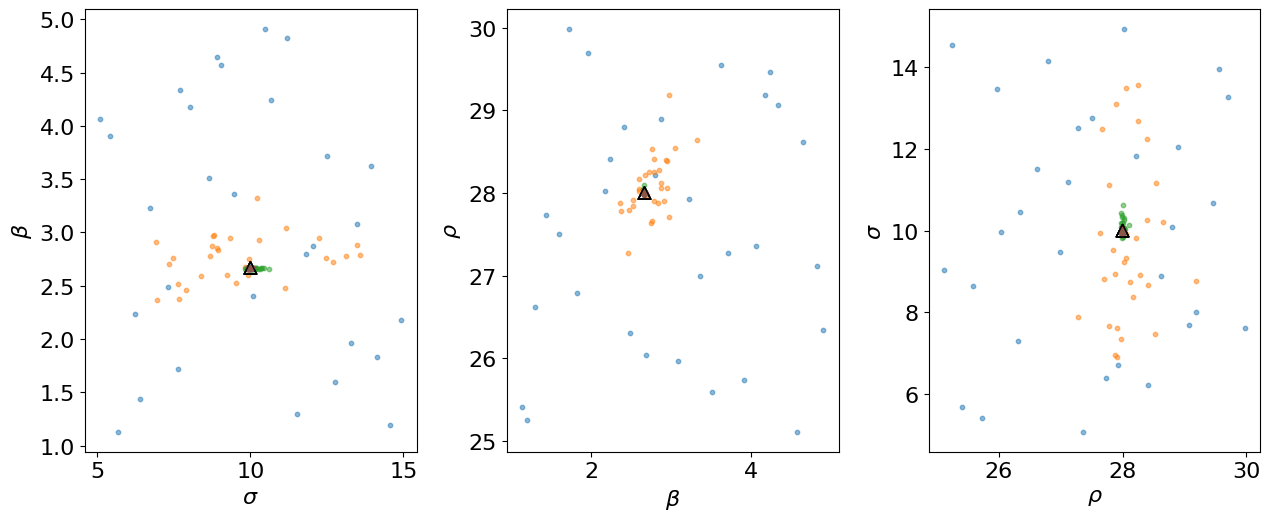

In [18]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in eki.parameters:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(true_params['sigma'],true_params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(true_params['beta'],true_params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(true_params['rho'],true_params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_eki.png',dpi=300) 

## d = 2

In [15]:
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask,HistoryMatchingBase
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.emulators import MultiTaskGPMatern
from abracalibra.summary import implausibility_multivariate_distr

class HistoryMatchingMultTaskLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(num_tasks=self.number_of_observables)
        # likelihood.noise = 1e-2
        model = MultiTaskGPMatern(
            parameters, observations,likelihood=likelihood, num_tasks=self.number_of_observables
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(500):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model 


parameters = ['sigma','rho']
priors = {
    'rho': Uniform(25,35),
    'sigma':Uniform(5,15)
} 
def summary(y,true_y):
    return implausibility_multivariate_distr(y,true_y)

fwd_d2 = ForwardModel(lorenz63,vectorized=False,beta=torch.as_tensor(true_params['beta']))
from scipy.stats import chi2


cutoff = torch.tensor(chi2(torch.linalg.matrix_rank(observables.covariance_matrix)).isf(0.01))
hm_d2 = HistoryMatchingMultTaskLorenz(parameters,priors,observables,ensemble_size=20,summary=summary,forward=fwd_d2,implausibility_cutoff=cutoff)
hm_d2.calibrate(1)

[Uniform(low: 5.0, high: 15.0), Uniform(low: 25.0, high: 35.0)]
tensor(6.1140) tensor(2.6667) tensor(33.6286)
tensor(5.8743) tensor(2.6667) tensor(34.7459)
tensor(5.2459) tensor(2.6667) tensor(30.8841)
tensor(9.1995) tensor(2.6667) tensor(26.8276)
tensor(7.9548) tensor(2.6667) tensor(25.6126)
tensor(9.6351) tensor(2.6667) tensor(31.9954)
tensor(14.8852) tensor(2.6667) tensor(29.8482)
tensor(11.0497) tensor(2.6667) tensor(26.2097)
tensor(12.4740) tensor(2.6667) tensor(32.4232)
tensor(13.4832) tensor(2.6667) tensor(33.0270)
tensor(11.9806) tensor(2.6667) tensor(30.0858)
tensor(13.7501) tensor(2.6667) tensor(28.4761)
tensor(8.1181) tensor(2.6667) tensor(31.0747)
tensor(7.2704) tensor(2.6667) tensor(28.5795)
tensor(12.7415) tensor(2.6667) tensor(32.9349)
tensor(14.2650) tensor(2.6667) tensor(29.1932)
tensor(10.8336) tensor(2.6667) tensor(27.6937)
tensor(8.7766) tensor(2.6667) tensor(25.2531)
tensor(10.0197) tensor(2.6667) tensor(34.0023)
tensor(6.6054) tensor(2.6667) tensor(27.2612)
Step 0

In [21]:
nroy,coords= hm_d2.nroy_over_support(num_points=250,return_coords=True)

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [22]:
hm_d2.implausibility(torch.tensor([10,28]),0)

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


tensor([8.2821], grad_fn=<CatBackward0>)

Text(0, 0.5, '$\\sigma$')

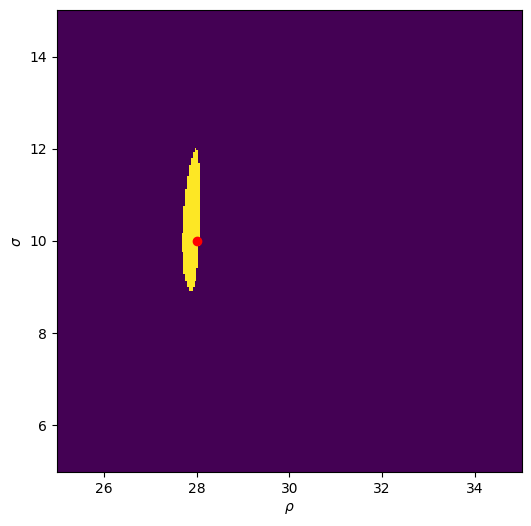

In [29]:
fig,ax = plt.subplots(1,1,figsize=(6,6))
X,Y = torch.meshgrid(coords[0],coords[1],indexing='ij')
ax.pcolormesh(Y,X,nroy)
ax.scatter(true_params['rho'],true_params['sigma'],color='r')
ax.set_xlabel('$\\rho$')
ax.set_ylabel('$\\sigma$')

In [19]:
parameters = ['rho',]
priors = {
    'rho':Uniform(25,30)
} 
def summary(y,true_y):
    return implausibility_multivariate_distr(y,true_y)

from scipy.stats import chi2


cutoff = torch.tensor(chi2(torch.linalg.matrix_rank(observables.covariance_matrix)).isf(0.01))

fwd_d1 = ForwardModel(lorenz63,vectorized=False,beta=torch.as_tensor(true_params['beta']),sigma=torch.as_tensor(true_params['sigma']))
hm_d1 = HistoryMatchingMultTaskLorenz(parameters,priors,observables,ensemble_size=10,summary=summary,forward=fwd_d1,implausibility_cutoff=cutoff)
hm_d1.calibrate(2)

[Uniform(low: 25.0, high: 30.0)]
tensor(10) tensor(2.6667) tensor(29.3502)
tensor(10) tensor(2.6667) tensor(27.9989)
tensor(10) tensor(2.6667) tensor(27.0964)
tensor(10) tensor(2.6667) tensor(28.4928)
tensor(10) tensor(2.6667) tensor(25.1447)
tensor(10) tensor(2.6667) tensor(25.5340)
tensor(10) tensor(2.6667) tensor(26.3173)
tensor(10) tensor(2.6667) tensor(26.6630)
tensor(10) tensor(2.6667) tensor(28.5250)
tensor(10) tensor(2.6667) tensor(29.7543)
Step 0 Loss: 9867.9677734375
Step 1 Loss: 9317.8681640625
Step 2 Loss: 8786.3779296875
Step 3 Loss: 8273.1982421875
Step 4 Loss: 7775.580078125
Step 5 Loss: 7290.59423828125
Step 6 Loss: 6817.08544921875
Step 7 Loss: 6354.7529296875
Step 8 Loss: 5903.87451171875
Step 9 Loss: 5464.76318359375
Step 10 Loss: 5038.16162109375
Step 11 Loss: 4625.873046875
Step 12 Loss: 4230.17431640625
Step 13 Loss: 3853.500244140625
Step 14 Loss: 3498.861083984375
Step 15 Loss: 3170.197998046875
Step 16 Loss: 2870.8095703125
Step 17 Loss: 2602.04150390625
Step 1

KeyboardInterrupt: 

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


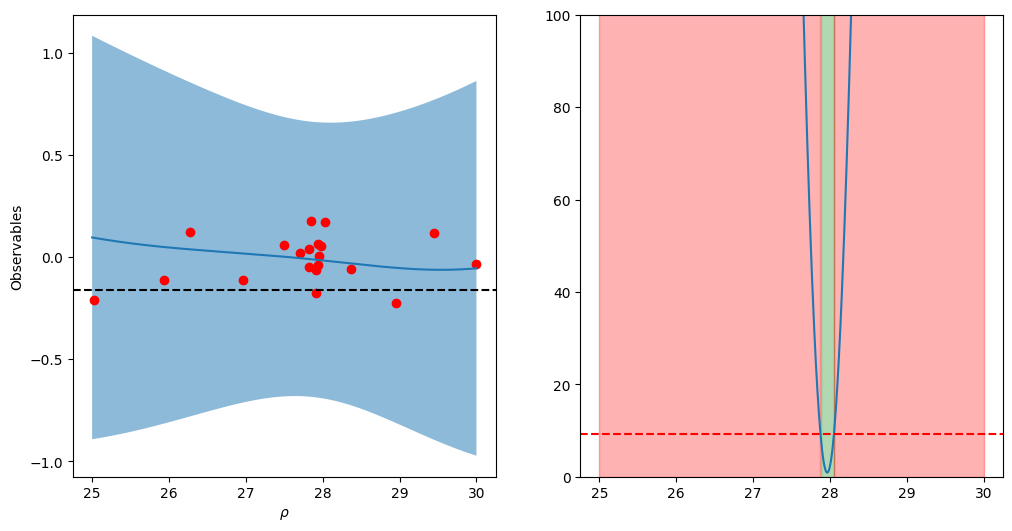

In [24]:
em = hm_d1.emulators[hm_d1.current_wave - 1]
rho = torch.linspace(25,30,500)
pred = em(rho.view(-1,1))
plot_var = 1
fig, (ax1,ax2)= plt.subplots(1,2,figsize=(12,6))
imp = hm_d1.implausibility(rho.view(-1,1),hm_d1.current_wave - 1)
with torch.no_grad():
    ax1.plot(rho,pred.mean[:,plot_var])
    lower,upper = pred.confidence_region()
    ax1.fill_between(rho,lower[:,plot_var],upper[:,plot_var],alpha=0.5)
    ax1.scatter(hm_d1.params[:,:,0].ravel(),hm_d1.results[:,:,plot_var].ravel(),color='r')
    ax1.axhline(observables.mean[plot_var],color='black',linestyle='--')
    ax1.set_xlabel('$\\rho$')
    ax1.set_ylabel('Observables')
    
    ax2.plot(rho,imp)
    ax2.set_ylim(0,100)
    ax2.axhline(hm_d1.implausibility_cutoff,color='r',linestyle='--')
    ax2.fill_between(rho,torch.zeros_like(rho),torch.ones_like(rho)*imp.max(),alpha=0.3,color='green',where=imp<9.2)
    ax2.fill_between(rho,torch.zeros_like(rho),torch.ones_like(rho)*imp.max(),alpha=0.3,color='red',where=imp>=9.2)
    


In [55]:
hm.results.shape

torch.Size([1, 100, 9])

### Lorenz96

In [ ]:
class Lorenz96Single(nn.Module):
    def __init__(self,F,*args, **kwargs):
        super().__init__(*args, **kwargs)
        self.F = torch.nn.Parameter(data=torch.as_tensor(F).double())
        
    def ode(self,t,r):
        return -torch.roll(r, shifts=-1, dims=-1) * (
            torch.roll(r, shifts=-2, dims=-1) - torch.roll(r, shifts=1, dims=-1)
        ) - r+ self.F
    
    def forward(self,x0,T,dt,spinup=10):
        t = torch.arange(0,T,dt)
        last = x0 
        r = x0.unsqueeze(-2)
        for i in range(len(t)-1):
            update = rk4_step(self.ode,t[i],last,dt)
            last = update 
            r = torch.cat([r,update.unsqueeze(-2)],dim=-2)
        return get_polynomial_features(r[...,int(spinup/dt):,:]).mean(dim=-2)
    

class Lorenz96TwoLevel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.F = torch.nn.Parameter(data=torch.as_tensor(10).double()) # Forcing of large scale
        self.c = torch.nn.Parameter(data=torch.as_tensor(10).double()) # Coupling between large and small scale
        self.h = torch.nn.Parameter(data=torch.as_tensor(1).double()) # Small scale time scale (fast)
        self.k = torch.nn.Parameter(data=torch.as_tensor(1).double()) # Small scale length scale 

    def ode(self,t,x,y):
        pass 

    def forward(self,x0,y0,T,dt,spinup = 10):
        pass


In [63]:
l96 = Lorenz96Single(1.4)
x0 = torch.ones((50,5)) + torch.rand_like(torch.ones((50,5)))*0.5
spinup = 10
T = 50
dt = 0.01
true_stats = l96(x0,T,dt,spinup)

In [81]:
mean_stats= true_stats.mean(dim=0)
covar = torch.cov(true_stats.T) + torch.eye(20)*1e-5 # P.S.D correction

obsl96 = MultivariateNormal(mean_stats,covar)

def lorenz96(F):
    with torch.no_grad():
        l = Lorenz96Single(F)    
        return l(x0,T,dt,spinup).mean(dim=0)
    
eki = EnsembleKalmanInversion(['F'],{'F':Uniform(1,2)},obsl96,ensemble_size=10,forward=ForwardModel(lorenz96,vectorized=False))

In [82]:
eki.calibrate(5)

tensor([1.3998], grad_fn=<MeanBackward1>)

In [93]:
hm = HistoryMatchingMultTaskLorenz(['F'],{'F':Uniform(1,2)},obsl96,ensemble_size=10,forward=ForwardModel(lorenz96,vectorized=False),summary=implausibility_multivariate_distr,implausibility_cutoff=9.2)
hm.calibrate(1)

Step 0 Loss: 1.3156030178070068
Step 1 Loss: 1.287278652191162
Step 2 Loss: 1.2599138021469116
Step 3 Loss: 1.233483076095581
Step 4 Loss: 1.207924723625183
Step 5 Loss: 1.1831772327423096
Step 6 Loss: 1.1591476202011108
Step 7 Loss: 1.1357160806655884
Step 8 Loss: 1.1127557754516602
Step 9 Loss: 1.0901464223861694
Step 10 Loss: 1.0677801370620728
Step 11 Loss: 1.045565128326416
Step 12 Loss: 1.0234301090240479
Step 13 Loss: 1.0013254880905151
Step 14 Loss: 0.9792230129241943
Step 15 Loss: 0.957111120223999
Step 16 Loss: 0.934985339641571
Step 17 Loss: 0.912842869758606
Step 18 Loss: 0.8906745910644531
Step 19 Loss: 0.8684631586074829
Step 20 Loss: 0.8461807370185852
Step 21 Loss: 0.8237937688827515
Step 22 Loss: 0.8012662529945374
Step 23 Loss: 0.7785655856132507
Step 24 Loss: 0.7556675672531128
Step 25 Loss: 0.7325610518455505
Step 26 Loss: 0.7092503905296326
Step 27 Loss: 0.6857539415359497
Step 28 Loss: 0.6621000170707703
Step 29 Loss: 0.6383162140846252
Step 30 Loss: 0.61442315578

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


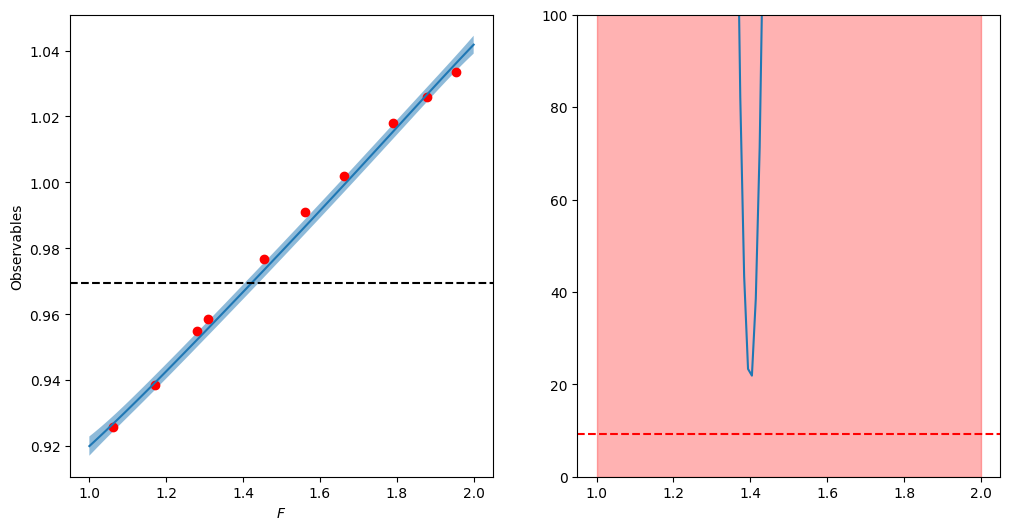

In [94]:
em = hm.emulators[hm.current_wave - 1]
F = torch.linspace(1,2,100)
pred = em(F.view(-1,1))
plot_var = 0
fig, (ax1,ax2)= plt.subplots(1,2,figsize=(12,6))
imp = hm.implausibility(F.view(-1,1),hm.current_wave - 1)
with torch.no_grad():
    ax1.plot(F,pred.mean[:,plot_var])
    lower,upper = pred.confidence_region()
    ax1.fill_between(F,lower[:,plot_var],upper[:,plot_var],alpha=0.5)
    ax1.scatter(hm.params[:,:,0].ravel(),hm.results[:,:,plot_var].ravel(),color='r')
    ax1.axhline(obsl96.mean[plot_var],color='black',linestyle='--')
    ax1.set_xlabel('$F$')
    ax1.set_ylabel('Observables')
    
    ax2.plot(F,imp)
    ax2.set_ylim(0,100)
    ax2.axhline(hm.implausibility_cutoff,color='r',linestyle='--')
    ax2.fill_between(F,torch.zeros_like(F),torch.ones_like(F)*imp.max(),alpha=0.3,color='green',where=imp<9.2)
    ax2.fill_between(F,torch.zeros_like(F),torch.ones_like(F)*imp.max(),alpha=0.3,color='red',where=imp>=9.2)
    


In [85]:
hm.nroy(torch.tensor([1.4]))

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


tensor([False])

In [ ]:
import numpy as np 

class L96TwoLevel(object):
    def __init__(self, K=36, J=10, h=1, F=10, c=10, b=10, dt=0.001,
                 X_init=None, Y_init=None, noprog=False, noYhist=False, save_dt=0.1,
                 integration_type='uncoupled', parameterization=None):
        # Model parameters
        self.K, self.J, self.h, self.F, self.c, self.b, self.dt = K, J, h, F, c, b, dt
        self.noprog, self.noYhist, self.integration_type = noprog, noYhist, integration_type
        self.step_count = 0
        self.save_dt = save_dt
        self.parameterization = parameterization
        if self.parameterization is not None: self.integration_type = 'parameterization'
        self.save_steps = int(save_dt / dt)
        self.X = np.random.rand(self.K) if X_init is None else X_init.copy()
        self.Y = np.zeros(self.K * self.J) if Y_init is None else Y_init.copy()
        self._history_X = [self.X.copy()]
        self._history_Y_mean = [self.Y.reshape(self.K, self.J).mean(1).copy()]
        self._history_Y2_mean = [(self.Y.reshape(self.K, self.J)**2).mean(1).copy()]
        self._history_B = [-self.h * self.c * self.Y.reshape(self.K, self.J).mean(1)]
        if not self.noYhist:
            self._history_Y = [self.Y.copy()]

    def _rhs_X_dt(self, X, Y=None, B=None):
        """Compute the right hand side of the X-ODE."""
        if Y is None:
            dXdt = (
                    -np.roll(X, -1) * (np.roll(X, -2) - np.roll(X, 1)) -
                    X + self.F + B
            )
        else:
            dXdt = (
                    -np.roll(X, -1) * (np.roll(X, -2) - np.roll(X, 1)) -
                    X + self.F - self.h * self.c * Y.reshape(self.K, self.J).mean(1)
            )
        return self.dt * dXdt

    def _rhs_Y_dt(self, X, Y):
        """Compute the right hand side of the Y-ODE."""
        dYdt = (
                       -self.b * np.roll(Y, 1) * (np.roll(Y, 2) - np.roll(Y, -1)) -
                       Y + self.h / self.J * np.repeat(X, self.J)
               ) * self.c
        return self.dt * dYdt

    def _rhs_dt(self, X, Y):
        return self._rhs_X_dt(X, Y=Y), self._rhs_Y_dt(X, Y)

    def step(self, add_B=True, B=None):
        """Integrate one time step"""
        if self.parameterization is None:
            B = -self.h * self.c * self.Y.reshape(self.K, self.J).mean(1) if B is None else B
            if self.integration_type == 'coupled':
                k1_X, k1_Y = self._rhs_dt(self.X, self.Y)
                k2_X, k2_Y = self._rhs_dt(self.X + k1_X / 2, self.Y + k1_Y / 2)
                k3_X, k3_Y = self._rhs_dt(self.X + k2_X / 2, self.Y + k2_Y / 2)
                k4_X, k4_Y = self._rhs_dt(self.X + k3_X, self.Y + k3_Y)
            elif self.integration_type == 'uncoupled':
                k1_X = self._rhs_X_dt(self.X, B=B)
                k2_X = self._rhs_X_dt(self.X + k1_X / 2, B=B)
                k3_X = self._rhs_X_dt(self.X + k2_X / 2, B=B)
                k4_X = self._rhs_X_dt(self.X + k3_X, B=B)
                # Then update Y with unupdated X
                k1_Y = self._rhs_Y_dt(self.X, self.Y)
                k2_Y = self._rhs_Y_dt(self.X, self.Y + k1_Y / 2)
                k3_Y = self._rhs_Y_dt(self.X, self.Y + k2_Y / 2)
                k4_Y = self._rhs_Y_dt(self.X, self.Y + k3_Y)

            self.X += 1 / 6 * (k1_X + 2 * k2_X + 2 * k3_X + k4_X)
            self.Y += 1 / 6 * (k1_Y + 2 * k2_Y + 2 * k3_Y + k4_Y)
        else:  # Parameterization case
            k1_X = self._rhs_X_dt(self.X, B=0)
            k2_X = self._rhs_X_dt(self.X + k1_X / 2, B=0)
            k3_X = self._rhs_X_dt(self.X + k2_X / 2, B=0)
            k4_X = self._rhs_X_dt(self.X + k3_X, B=0)

            B = self.parameterization(self.X) if B is None else B
            self.X += 1 / 6 * (k1_X + 2 * k2_X + 2 * k3_X + k4_X)
            if add_B: self.X += B * self.dt

        self.step_count += 1
        if self.step_count % self.save_steps == 0:
            Y_mean = self.Y.reshape(self.K, self.J).mean(1)
            Y2_mean = (self.Y.reshape(self.K, self.J)**2).mean(1)
            self._history_X.append(self.X.copy())
            self._history_Y_mean.append(Y_mean.copy())
            self._history_Y2_mean.append(Y2_mean.copy())
            self._history_B.append(B.copy())
            if not self.noYhist:
                self._history_Y.append(self.Y.copy())

    def iterate(self, time):
        from tqdm import tqdm 
        steps = int(time / self.dt)
        for n in tqdm(range(steps), disable=self.noprog):
            self.step()

    @property
    def state(self):
        return np.concatenate([self.X, self.Y])

    def set_state(self, x):
        self.X = x[:self.K]
        self.Y = x[self.K:]

    @property
    def parameters(self):
        return np.array([self.F, self.h, self.c, self.b])

    def erase_history(self):
        self._history_X = []
        self._history_Y_mean = []
        self._history_Y2_mean = []
        self._history_B = []
        if not self.noYhist:
            self._history_Y = []

    @property
    def history(self):
        import xarray as xr 
        dic = {}
        dic['X'] = xr.DataArray(self._history_X, dims=['time', 'x'], name='X')
        dic['B'] = xr.DataArray(self._history_B, dims=['time', 'x'], name='B')
        dic['Y_mean'] = xr.DataArray(self._history_Y_mean, dims=['time', 'x'], name='Y_mean')
        dic['Y2_mean'] = xr.DataArray(self._history_Y2_mean, dims=['time', 'x'], name='Y2_mean')
        if not self.noYhist:
            dic['X_repeat'] = xr.DataArray(np.repeat(self._history_X, self.J, 1),
                                   dims=['time', 'y'], name='X_repeat')
            dic['Y'] = xr.DataArray(self._history_Y, dims=['time', 'y'], name='Y')
        return xr.Dataset(
            dic,
            coords={'time': np.arange(len(self._history_X)) * self.save_dt, 'x': np.arange(self.K),
                    'y': np.arange(self.K * self.J)}
        )

    def mean_stats(self, ax=None, fn=np.mean):
        h = self.history
        return np.concatenate([
            np.atleast_1d(fn(h.X, ax)),
            np.atleast_1d(fn(h.Y_mean, ax)),
            np.atleast_1d(fn((h.X ** 2), ax)),
            np.atleast_1d(fn((h.X * h.Y_mean), ax)),
            np.atleast_1d(fn(h.Y2_mean, ax))
        ])

In [ ]:
def lorenz962lvl( h,c,b,F):
    for _ in range(1):
        l96 = L96TwoLevel(K=16,h=h.item(),c=c.item(),b=b.item(),F=F.item())
        l96.iterate(50)
        return torch.as_tensor(np.concatenate([np.stack(l96._history_X).mean(axis=0),(np.stack(l96._history_X)**2).mean(axis=0)])).float()


In [ ]:


for _ in range(10):
    l96 = L96TwoLevel(K=16,h=h.item(),c=c.item(),b=b.item(),F=F.item())
    l96.iterate(50)
    torch.as_tensor(np.concatenate([np.stack(l96._history_X).mean(axis=0),(np.stack(l96._history_X)**2).mean(axis=0)])).float()


100%|██████████| 50000/50000 [00:07<00:00, 6729.27it/s]


torch.float64

In [172]:
mean_stats = stats.mean(dim=0).float()
covar_stats = torch.cov(stats.T).float()
print(torch.linalg.matrix_rank(covar_stats))
covar_stats += torch.eye(32)*1e-5

tensor(9)


In [173]:
obsl962lvl = MultivariateNormal(mean_stats,covar_stats)

In [37]:
l96.ode(1,torch.arange(0,1,0.1))

tensor([1.0700, 0.8400, 0.7100, 0.5800, 0.4500, 0.3200, 0.1900, 0.0600, 0.8300,
        0.1000], grad_fn=<AddBackward0>)

In [ ]:
from torch.distributions import MultivariateNormal,Normal
priors = {
    'h':Uniform(0.5,1.5),
    'c':Uniform(5,15),
    'b':Uniform(5,15),
    'F':Normal(10,5),
}
parameters = ['h','c','b','F']
eki = EnsembleKalmanInversion(parameters,priors,obsl962lvl,ensemble_size=40,forward=ForwardModel(lorenz962lvl,vectorized=False))
eki.calibrate(5) 

 69%|██████▉   | 34699/50000 [00:05<00:02, 6488.28it/s]


KeyboardInterrupt: 

In [32]:
hm = HistoryMatchingMultTaskLorenz(parameters,priors,obsl962lvl,ensemble_size=40,forward=ForwardModel(lorenz962lvl,vectorized=False))

NameError: name 'obsl962lvl' is not defined

100%|██████████| 50000/50000 [00:07<00:00, 6862.35it/s]


tensor([ 1.1612,  7.6283,  9.1909, 10.0414])

In [ ]:
eki.calibrate(2)

['h', 'c', 'J', 'F']